# Sleep Logs Analysis

# Intro

This article intends to provide complete analysis of given sleep logs. The purposes of the analysis are: 

- Ensure the quality of sleep at the present time;
- Define main external and internal factors influence the quality of sleep and well being;
- Develop a plan to improve, maintain, and enhance quality of sleep.

The information presented here will be more focused on the analysis data itself than its preparing and formatting techniques. But it will have well documented source code and brief explanations in the article itself.

# Data and Methodology

Future methods of processing the data depends on given sources. There will be presented data from two distinct tables of different formats: **markdown** - `.md`, and **comma-separated values (CSV)** - `.txt` or `.csv`. The data of these sources must follow common table structure for future processing and interpreting. That's why these files will undergo several stages of the preparatory process, **scv-source** table's format chosen as more preferable due it's data precision:

1. Fetching **markdown** table by title (source code `md_extract`):
   This is performed in `md_extract.py` by using such packages as [Markdown](https://pypi.org/project/Markdown/) and [Beautiful Soup](https://pypi.org/project/beautifulsoup4/);
4. Renaming columns of the **md-source** table to match the names of the **csv-source** table;
5. Adding new and removing unnecessry columns to the **md-source** for compatibility with **csv-source**;
6. Changing `Duration` column to timestamp to make it easier to operate with;
7. Generate dates for rows, **md-source** has data aranged sequentially in ascending date order.
   The earliest day of the **csv_source** used for generation;
8. Formatting **Sleep Time** and **Wake Time** of the both tables.
9. Finallization: tables concatination and setting dtypes.

# Imports and table verification

In [1]:
# Standard library
import re
import math

# Standard data science tools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Custom utilities
import preparation as prep
import viz

In [2]:
prep.sleep_logs.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 64 entries, 2025-10-16 to 2025-12-18
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype          
---  ------      --------------  -----          
 0   Sleep Time  64 non-null     object         
 1   Wake Time   64 non-null     object         
 2   Duration    64 non-null     timedelta64[ns]
 3   Notes       38 non-null     object         
dtypes: object(3), timedelta64[ns](1)
memory usage: 2.5+ KB


# Sleep Time Variability

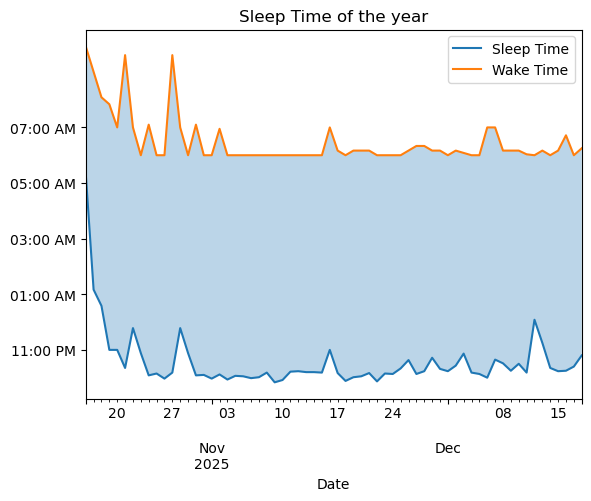

In [3]:
df = prep.sleep_logs[['Sleep Time', 'Wake Time']]

# Convert objects to timedeltas
df = df.apply(lambda s: pd.to_datetime(s, format="%I:%M %p") - 
              pd.to_datetime("1900-01-01"))
# Fit timedetas
inc = lambda dt: np.timedelta64(24, 'h') + dt
condition = prep.sleep_logs['Sleep Time'].str.match(r'\d\d:\d\d AM').values
df['Sleep Time'] = df['Sleep Time'].mask(condition, inc)
df['Wake Time'] = df['Wake Time'].apply(inc)
# Normalize
df = df.map(lambda td: td / pd.to_timedelta('1 d'))

ax = df.plot()
viz.theme_sleeptime_plt(ax, df)
plt.show()

# Duration

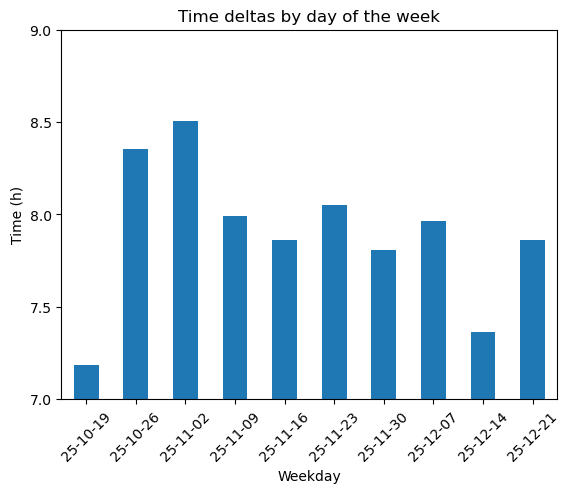

In [4]:
to_hours = lambda td: td.seconds / 3600

df = (
    prep.sleep_logs[['Duration']]
    .resample('W')
    .mean()
    # Normalize. Duration in hours
    .map(to_hours)
)

ax = df.plot.bar(legend=None)
viz.theme_durations_barplt(ax, df)
ax.set_title("Time deltas by day of the week")
ax.set_ylabel("Time (h)")
ax.set_xlabel("Weekday")
plt.show()

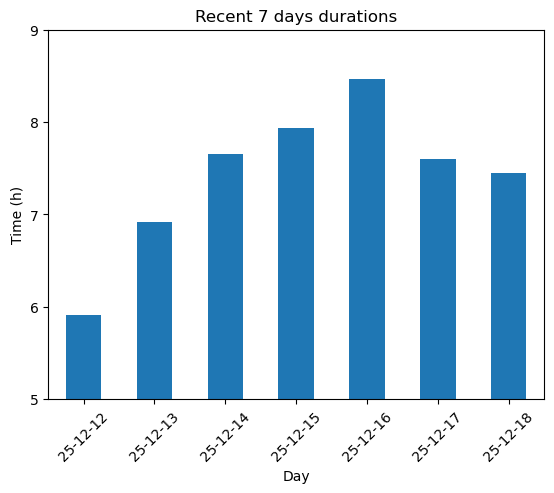

In [5]:
df = (
    prep.sleep_logs[['Duration']]
    .tail(7)
    .map(to_hours)
)

ax = df.plot.bar(legend=None)
viz.theme_durations_barplt(ax, df)
ax.set_title("Recent 7 days durations")
ax.set_ylabel("Time (h)")
ax.set_xlabel("Day")
plt.show()

# Boxplot

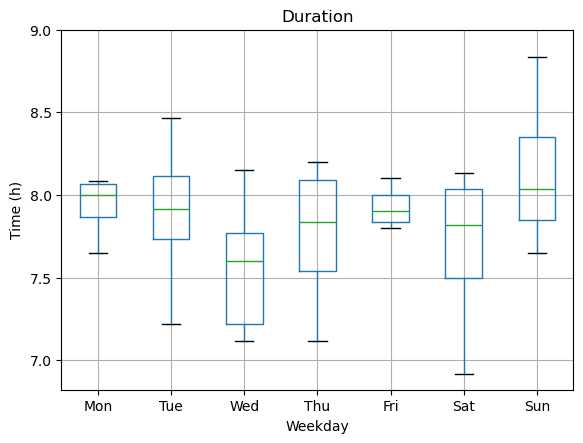

In [6]:
df = prep.sleep_logs[['Duration']].map(to_hours)

df['Day'] = prep.sleep_logs.index.isocalendar().day

ax = df.boxplot(by='Day', sym='')
viz.theme_weekdays_boxplt(ax, df)
ax.set_ylabel("Time (h)")
ax.set_xlabel("Weekday")
plt.show()

# References

- [Markdown Official Website](https://daringfireball.net/projects/markdown/)
- [Beautiful Soup Official Website](https://www.crummy.com/software/BeautifulSoup/)
- [Markdown in PyPI](https://pypi.org/project/Markdown/)
- [Beautiful Soup in PyPI](https://pypi.org/project/beautifulsoup4/)